## 1. Dataset Overview
# Customer Churn Analysis for a B2B SaaS Company

## 1. Business Problem

Customer churn is a critical challenge for subscription-based businesses, as losing existing customers directly impacts recurring revenue and long-term growth. Acquiring new customers is often more expensive than retaining current ones, making customer retention a key business priority.

The objective of this project is to analyze customer behavior, identify factors associated with churn, and generate insights that can help the business improve customer retention and customer lifetime value.

---

## 2. Dataset Overview

This dataset contains customer-level information from a UK-based B2B SaaS company. Each record represents a customer organization and includes information related to company demographics, subscription details, product usage, customer engagement, support interactions, financial metrics, and churn status.

The dataset is synthetic but designed to reflect realistic business scenarios commonly observed in subscription-based software companies.

---

## 3. Dataset Shape

The dataset contains customer records along with multiple features describing customer characteristics, engagement patterns, subscription details, and revenue-related information.

The exact number of rows and columns will be obtained directly from the dataset during analysis.

---

## 4. Data Dictionary

The dataset includes the following categories of information:

### Customer Information
- Customer demographics and organizational characteristics.
- Examples: region, industry, company size, employee count.

### Subscription Information
- Customer subscription and contract details.
- Examples: subscription plan, contract type, tenure, subscription fee.

### Product Usage Metrics
- Measures of product adoption and platform usage.
- Examples: monthly logins, active users, projects created, feature usage score.

### Customer Support Metrics
- Information related to customer support interactions.
- Examples: support tickets, resolution time, payment failures.

### Engagement Metrics
- Indicators of customer engagement with the platform.
- Examples: email open rate, webinar attendance.

### Financial Metrics
- Revenue and customer value measures.
- Examples: monthly recurring revenue and lifetime value.

### Target Variable
- `churn` indicates whether a customer has discontinued the service.

---

## 5. Business Questions

The analysis aims to answer the following questions:

1. What is the overall customer churn rate?
2. Which customer segments experience the highest churn?
3. Does contract type influence customer retention?
4. How does customer engagement impact churn behavior?
5. What relationship exists between product usage and churn?
6. Which industries exhibit the highest churn rates?
7. Do customer support interactions influence retention?
8. Which acquisition channels generate the most valuable customers?
9. What factors appear to be the strongest drivers of churn?
10. How can the business proactively identify customers at risk of churn?

### 6. Analytical Objectives

The primary objectives of this analysis are:

- Understand customer demographics and behavior.
- Analyze customer engagement and product adoption.
- Evaluate revenue and customer lifetime value patterns.
- Identify key drivers of customer churn.
- Generate actionable business insights.
- Develop customer retention recommendations.
- Build predictive models to identify at-risk customers.

---

### 7. Project Workflow

The project follows a complete machine learning lifecycle, from raw data ingestion to cloud deployment.

1. Data Understanding
2. Data Quality Assessment
3. Data Cleaning and Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Train-Test Split
7. Data Transformation and Encoding
8. Model Training
9. Model Evaluation and Selection
10. Hyperparameter Tuning
11. Model Serialization (Model Saving)
12. Prediction Pipeline Development
13. Flask Application Development
14. AWS Cloud Deployment
15. Model Monitoring and Maintenance

---

### 8. Expected Outcomes

By the end of this project, the following deliverables are expected:

- A cleaned and preprocessed customer churn dataset.
- Identification of key drivers influencing customer churn.
- Engineered features that improve model performance.
- A machine learning model capable of predicting customer churn.
- Evaluation and comparison of multiple machine learning algorithms.
- A reusable training pipeline for automated model retraining.
- A prediction pipeline capable of processing new customer data.
- A Flask web application for churn prediction.
- Deployment-ready machine learning artifacts:
  - preprocessor.pkl
  - model.pkl
- An end-to-end machine learning solution deployed on AWS Cloud.
- Actionable business insights to support customer retention strategies.

---

### 9. Project Architecture

```text
Raw Dataset
     ↓
Data Ingestion
     ↓
Data Transformation
     ↓
Feature Engineering
     ↓
Model Training
     ↓
Model Evaluation
     ↓
Best Model Selection
     ↓
model.pkl + preprocessor.pkl
     ↓
Prediction Pipeline
     ↓
Flask Web Application
     ↓
AWS EC2 Deployment
     ↓
End Users
```

## 2. Data Quality Assessment


In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("data/raw_data.csv")

In [3]:
df.head().T

,0,1,2,3,4
customer_id,CF00001,CF00002,CF00003,CF00004,CF00005
region,North West,East Midlands,Scotland,West Midlands,North West
subscription_plan,Professional,Starter,Starter,Professional,Professional
contract_type,Monthly,Monthly,Monthly,Annual,Monthly
tenure_months,3,1,14,16,1
monthly_logins,42.0,45.0,59.0,2500.0,50.0
customer_satisfaction_score,2.0,7.0,4.0,7.0,10.0
industry,Technology,Retail,Healthcare,Logistics,Education
company_size,Medium,Small,Small,Small,Micro
years_in_business,30,15,3,1,15


In [4]:
df.shape

(15606, 30)

**Insight**

From here we can see the dataset contains **15606 rows and 30 columns**

In [5]:
df.columns

Index(['customer_id', 'region', 'subscription_plan', 'contract_type',
       'tenure_months', 'monthly_logins', 'customer_satisfaction_score',
       'industry', 'company_size', 'years_in_business',
       'monthly_subscription_fee_gbp', 'discount_percentage', 'employee_count',
       'active_users', 'feature_usage_score', 'avg_session_duration_minutes',
       'projects_created', 'integrations_enabled', 'support_tickets_last_6m',
       'avg_resolution_time_hours', 'payment_failures_last_12m',
       'email_open_rate', 'webinar_attendance_count',
       'monthly_recurring_revenue', 'lifetime_value', 'signup_date',
       'last_login_date', 'customer_segment', 'acquisition_channel', 'churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15606 entries, 0 to 15605
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   15606 non-null  object 
 1   region                        15606 non-null  object 
 2   subscription_plan             15606 non-null  object 
 3   contract_type                 15606 non-null  object 
 4   tenure_months                 15606 non-null  int64  
 5   monthly_logins                13428 non-null  float64
 6   customer_satisfaction_score   13403 non-null  float64
 7   industry                      15606 non-null  object 
 8   company_size                  15606 non-null  object 
 9   years_in_business             15606 non-null  int64  
 10  monthly_subscription_fee_gbp  15606 non-null  int64  
 11  discount_percentage           15606 non-null  int64  
 12  employee_count                15606 non-null  int64  
 13  a

### Insight

The dataset contains a mix of numerical, categorical, and datetime-related variables. Data types appear consistent with the business meaning of each feature, indicating that the dataset is suitable for further quality assessment and exploratory analysis.

### 2.1 Missing Value Analysis

In [7]:
df.isnull().sum()

customer_id                        0
region                             0
subscription_plan                  0
contract_type                      0
tenure_months                      0
monthly_logins                  2178
customer_satisfaction_score     2203
industry                           0
company_size                       0
years_in_business                  0
monthly_subscription_fee_gbp       0
discount_percentage                0
employee_count                     0
active_users                       0
feature_usage_score             2242
avg_session_duration_minutes    2220
projects_created                   0
integrations_enabled               0
support_tickets_last_6m            0
avg_resolution_time_hours          0
payment_failures_last_12m          0
email_open_rate                 2734
webinar_attendance_count           0
monthly_recurring_revenue          0
lifetime_value                     0
signup_date                        0
last_login_date                    0
c

In [8]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage":
    round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_values[
    missing_values["Missing Count"] > 0
].sort_values(
    by="Missing Count",
    ascending=False
)

,Missing Count,Missing Percentage
email_open_rate,2734,17.52
feature_usage_score,2242,14.37
avg_session_duration_minutes,2220,14.23
customer_satisfaction_score,2203,14.12
monthly_logins,2178,13.96


**Insight:**

The dataset contains missing values in five numerical variables. The highest level of missingness is observed in `email_open_rate` (17.52%), followed by `feature_usage_score`, `avg_session_duration_minutes`, `customer_satisfaction_score`, and `monthly_logins` (approximately 12–15%).

Since these variables are important customer engagement and product usage metrics, removing records would result in a significant loss of data. Therefore, an imputation-based approach is more appropriate.

### Handling Strategy

- Numerical missing values will be imputed using the **median** value.
- Median imputation is preferred because it is robust to outliers and preserves the overall distribution of the data.
- Missing value handling will be implemented within the preprocessing pipeline to ensure consistent treatment during both training and prediction.

### 2.2 Duplicate Record Analysis

In [9]:
df.duplicated().sum()
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 347


### Insight

A total of **347 duplicate records** were identified in the dataset. Although duplicates represent a small proportion of the overall data, 

they may lead to biased analysis and model performance if left unaddressed.

#### Handling Strategy

- Remove duplicate records using `drop_duplicates()`.
- Retain only unique observations for further analysis and model training.

### 2.3 Inconsistent Category Analysis

In [10]:
categorical_features = df.select_dtypes(
    include=['string', 'object']
).columns.tolist()

print(categorical_features)

['customer_id', 'region', 'subscription_plan', 'contract_type', 'industry', 'company_size', 'signup_date', 'last_login_date', 'customer_segment', 'acquisition_channel', 'churn']


In [11]:
categorical_cols = [
    "region",
    "subscription_plan",
    "contract_type",
    "industry",
    "company_size",
    "customer_segment",
    "acquisition_channel",
    "churn"
]

for col in categorical_cols:
    print(f"\n{'='*70}")
    print(f"Column: {col}")
    print(f"Unique Categories: {df[col].nunique()}")
    print(f"{'='*70}")
    print(sorted(df[col].astype(str).unique()))


Column: region
Unique Categories: 21
[' London ', ' Scotland ', ' South East ', ' Wales ', 'East Midlands', 'LONDON', 'London', 'North East', 'North West', 'SCOTLAND', 'SOUTH EAST', 'Scotland', 'South East', 'South West', 'WALES', 'Wales', 'West Midlands', 'london', 'scotland', 'south east', 'wales']

Column: subscription_plan
Unique Categories: 3
['Enterprise', 'Professional', 'Starter']

Column: contract_type
Unique Categories: 2
['Annual', 'Monthly']

Column: industry
Unique Categories: 7
['Education', 'Finance', 'Healthcare', 'Logistics', 'Manufacturing', 'Retail', 'Technology']

Column: company_size
Unique Categories: 4
['Large', 'Medium', 'Micro', 'Small']

Column: customer_segment
Unique Categories: 3
['Enterprise', 'Mid-Market', 'SMB']

Column: acquisition_channel
Unique Categories: 6
['Direct', 'Google Ads', 'LinkedIn', 'Organic Search', 'Partner', 'Referral']

Column: churn
Unique Categories: 2
['No', 'Yes']


### Insight

The review of categorical variables identified formatting inconsistencies in the `region` column. Although the dataset is expected to contain a limited number of UK regions, variations in capitalization and leading/trailing spaces resulted in multiple representations of the same region.

For example, values such as `London`, `london`, `LONDON`, and ` London ` refer to the same geographic location but are recorded in different formats. Similar inconsistencies were observed for regions such as Scotland, South East, and Wales.

These inconsistencies artificially increase the number of unique categories and may lead to misleading analysis, unnecessary category expansion during encoding, and reduced model efficiency.

No consistency issues were identified in the remaining categorical variables, including `subscription_plan`, `contract_type`, `industry`, `company_size`, `customer_segment`, `acquisition_channel`, and `churn`.

### Handling Strategy

The `region` column will be standardized by removing leading and trailing spaces and converting all values to a consistent title-case format. This will ensure accurate category representation, improve data quality, and support more reliable exploratory analysis and predictive modeling.

### 2.4 Invalid Value Analysis

In [12]:
invalid_values = {
    "Customer Satisfaction > 10":
        df[df["customer_satisfaction_score"] > 10].shape[0],

    "Customer Satisfaction < 1":
        df[df["customer_satisfaction_score"] < 1].shape[0],

    "Email Open Rate Outside 0-100":
        df[
            (df["email_open_rate"] > 100) |
            (df["email_open_rate"] < 0)
        ].shape[0],

    "Discount Percentage Outside 0-100":
        df[
            (df["discount_percentage"] > 100) |
            (df["discount_percentage"] < 0)
        ].shape[0],

    "Negative Tenure":
        df[df["tenure_months"] < 0].shape[0],

    "Active Users > Employee Count":
        df[
            df["active_users"] >
            df["employee_count"]
        ].shape[0],

    "Non-Positive Subscription Fee":
        df[
            df["monthly_subscription_fee_gbp"] <= 0
        ].shape[0],

    "Non-Positive Lifetime Value":
        df[
            df["lifetime_value"] <= 0
        ].shape[0]
}

pd.DataFrame(
    invalid_values.items(),
    columns=["Validation Check", "Invalid Count"]
)

,Validation Check,Invalid Count
0,Customer Satisfaction > 10,98
1,Customer Satisfaction < 1,0
2,Email Open Rate Outside 0-100,0
3,Discount Percentage Outside 0-100,0
4,Negative Tenure,59
5,Active Users > Employee Count,0
6,Non-Positive Subscription Fee,0
7,Non-Positive Lifetime Value,0


### Insight

The dataset was evaluated against predefined business rules and domain constraints to identify invalid values.

The analysis identified two categories of invalid observations. A total of **98 records** contain customer satisfaction scores greater than 10, exceeding the valid rating scale of 1 to 10. Additionally, **59 records** contain negative tenure values, which are not logically possible in a customer subscription lifecycle.

No invalid values were detected in email open rates, discount percentages, active user counts, subscription fees, or lifetime value metrics. These variables comply with their expected business rules and value ranges.

### Handling Strategy

The identified invalid values will be corrected during data preprocessing. Customer satisfaction scores exceeding the valid range will be capped at 10, while negative tenure values will be converted to positive values to maintain consistency with business logic.

These corrections will improve data quality and ensure more reliable exploratory analysis and model development.

### 2.5 Outlier Analysis

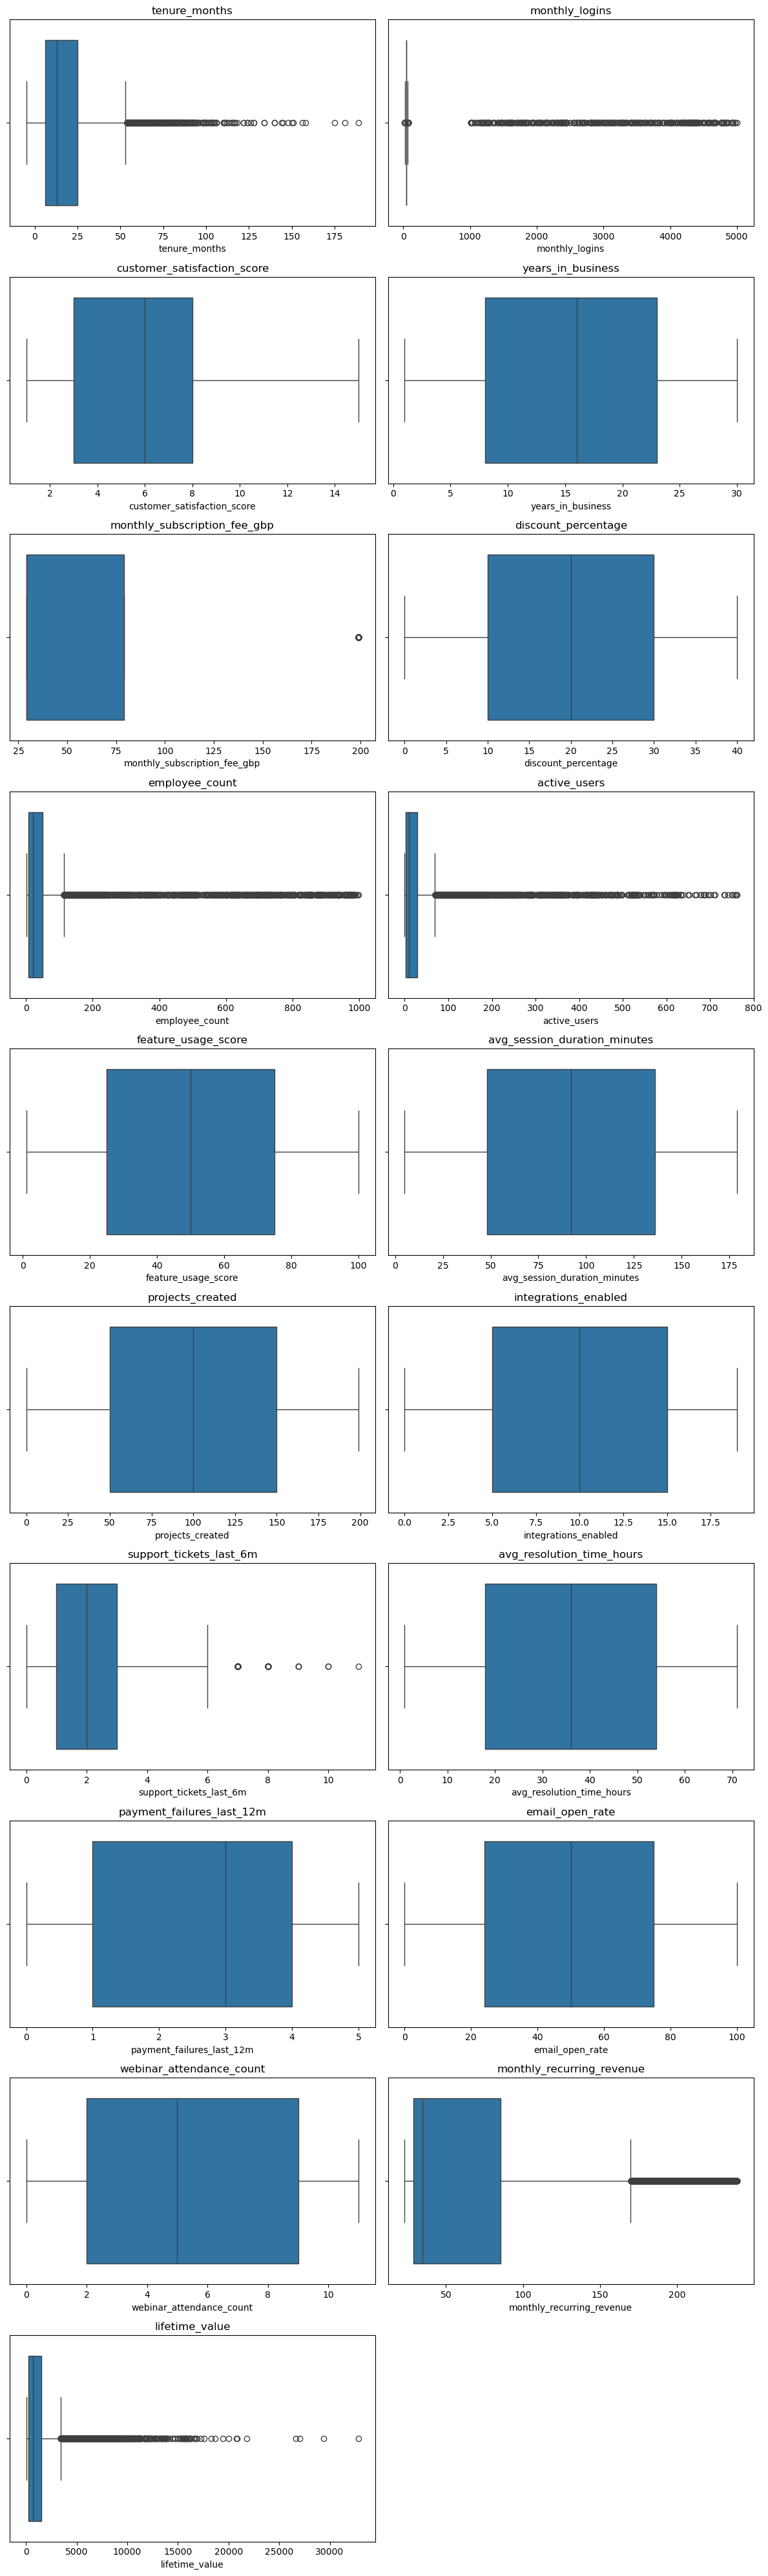

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Insight

Outlier analysis was performed using boxplots to identify extreme observations across numerical variables.

Several variables, including `monthly_logins`, `tenure_months`, `employee_count`, `active_users`, `monthly_recurring_revenue`, `lifetime_value`, and `support_tickets_last_6m`, contain observations that fall outside the typical range of values.

From a business perspective, these observations may represent highly engaged customers, large enterprise organizations, long-tenure customers, high-value accounts, or customers requiring increased support. The majority of these values appear plausible and do not immediately indicate data quality issues.

The `monthly_subscription_fee_gbp` variable also shows a small number of observations identified as outliers by statistical rules. However, these values correspond to valid subscription pricing tiers and are therefore considered legitimate business observations.

### Handling Strategy

The identified outliers will be retained for further analysis and model development. Removing these observations could result in the loss of important business information and reduce the model's ability to learn from real-world customer behavior.

If required, appropriate preprocessing techniques such as feature scaling or transformation will be considered during the modeling stage to reduce the influence of extreme values.

## 2.6 Creation of EDA Dataset

In [14]:
eda_df = df.copy() # creating new dataframe for EDA and cleaning to avoid modifying the original dataframe


# Handling duplicate rows

eda_df = eda_df.drop_duplicates()
print(
    f"Duplicate rows after cleaning: "
    f"{eda_df.duplicated().sum()}"
)

# Handling inconsistent formate in region column

eda_df["region"] = (
    eda_df["region"]
    .str.strip() #Removes leading and trailing spaces.(e.g., "  London  " becomes "London")
    .str.title() #Converts text to Title Case. (e.g., "LONDON,london,London" becomes "London")
)
print(f"Unique regions: {sorted(eda_df['region'].unique())}")


# handling invalid values in customer satisfaction score and tenure_months columns

# Fix customer satisfaction score
eda_df["customer_satisfaction_score"] = (
    eda_df["customer_satisfaction_score"]
    .clip(1, 10)
)

# Fix negative tenure
eda_df["tenure_months"] = (
    eda_df["tenure_months"]
    .abs()
)

invalid_values_after = {
    "Customer Satisfaction > 10":
        eda_df[eda_df["customer_satisfaction_score"] > 10].shape[0],

    "Negative Tenure":
        eda_df[eda_df["tenure_months"] < 0].shape[0]
}

pd.DataFrame(
    invalid_values_after.items(),
    columns=["Validation Check", "Invalid Count"]
)

Duplicate rows after cleaning: 0
Unique regions: ['East Midlands', 'London', 'North East', 'North West', 'Scotland', 'South East', 'South West', 'Wales', 'West Midlands']


,Validation Check,Invalid Count
0,Customer Satisfaction > 10,0
1,Negative Tenure,0


In [15]:
print("Original Shape :", df.shape)
print("EDA Shape      :", eda_df.shape)

Original Shape : (15606, 30)
EDA Shape      : (15259, 30)


### Insight

A separate EDA dataset was created to preserve the original raw data while applying corrections required for exploratory analysis.

The following adjustments were performed:

- Removed duplicate records.
- Standardized category formatting in the `region` column.
- Corrected invalid customer satisfaction scores.
- Corrected negative tenure values.

These changes improve data consistency and ensure that subsequent visualizations and business insights are based on a cleaner and more reliable version of the dataset.

The original dataset remains unchanged and will be processed separately through the machine learning preprocessing pipeline during model development.

# 3. EDA (Exploratory Data Analysis)

## 3.1 Univariate Analysis (Single Variable)

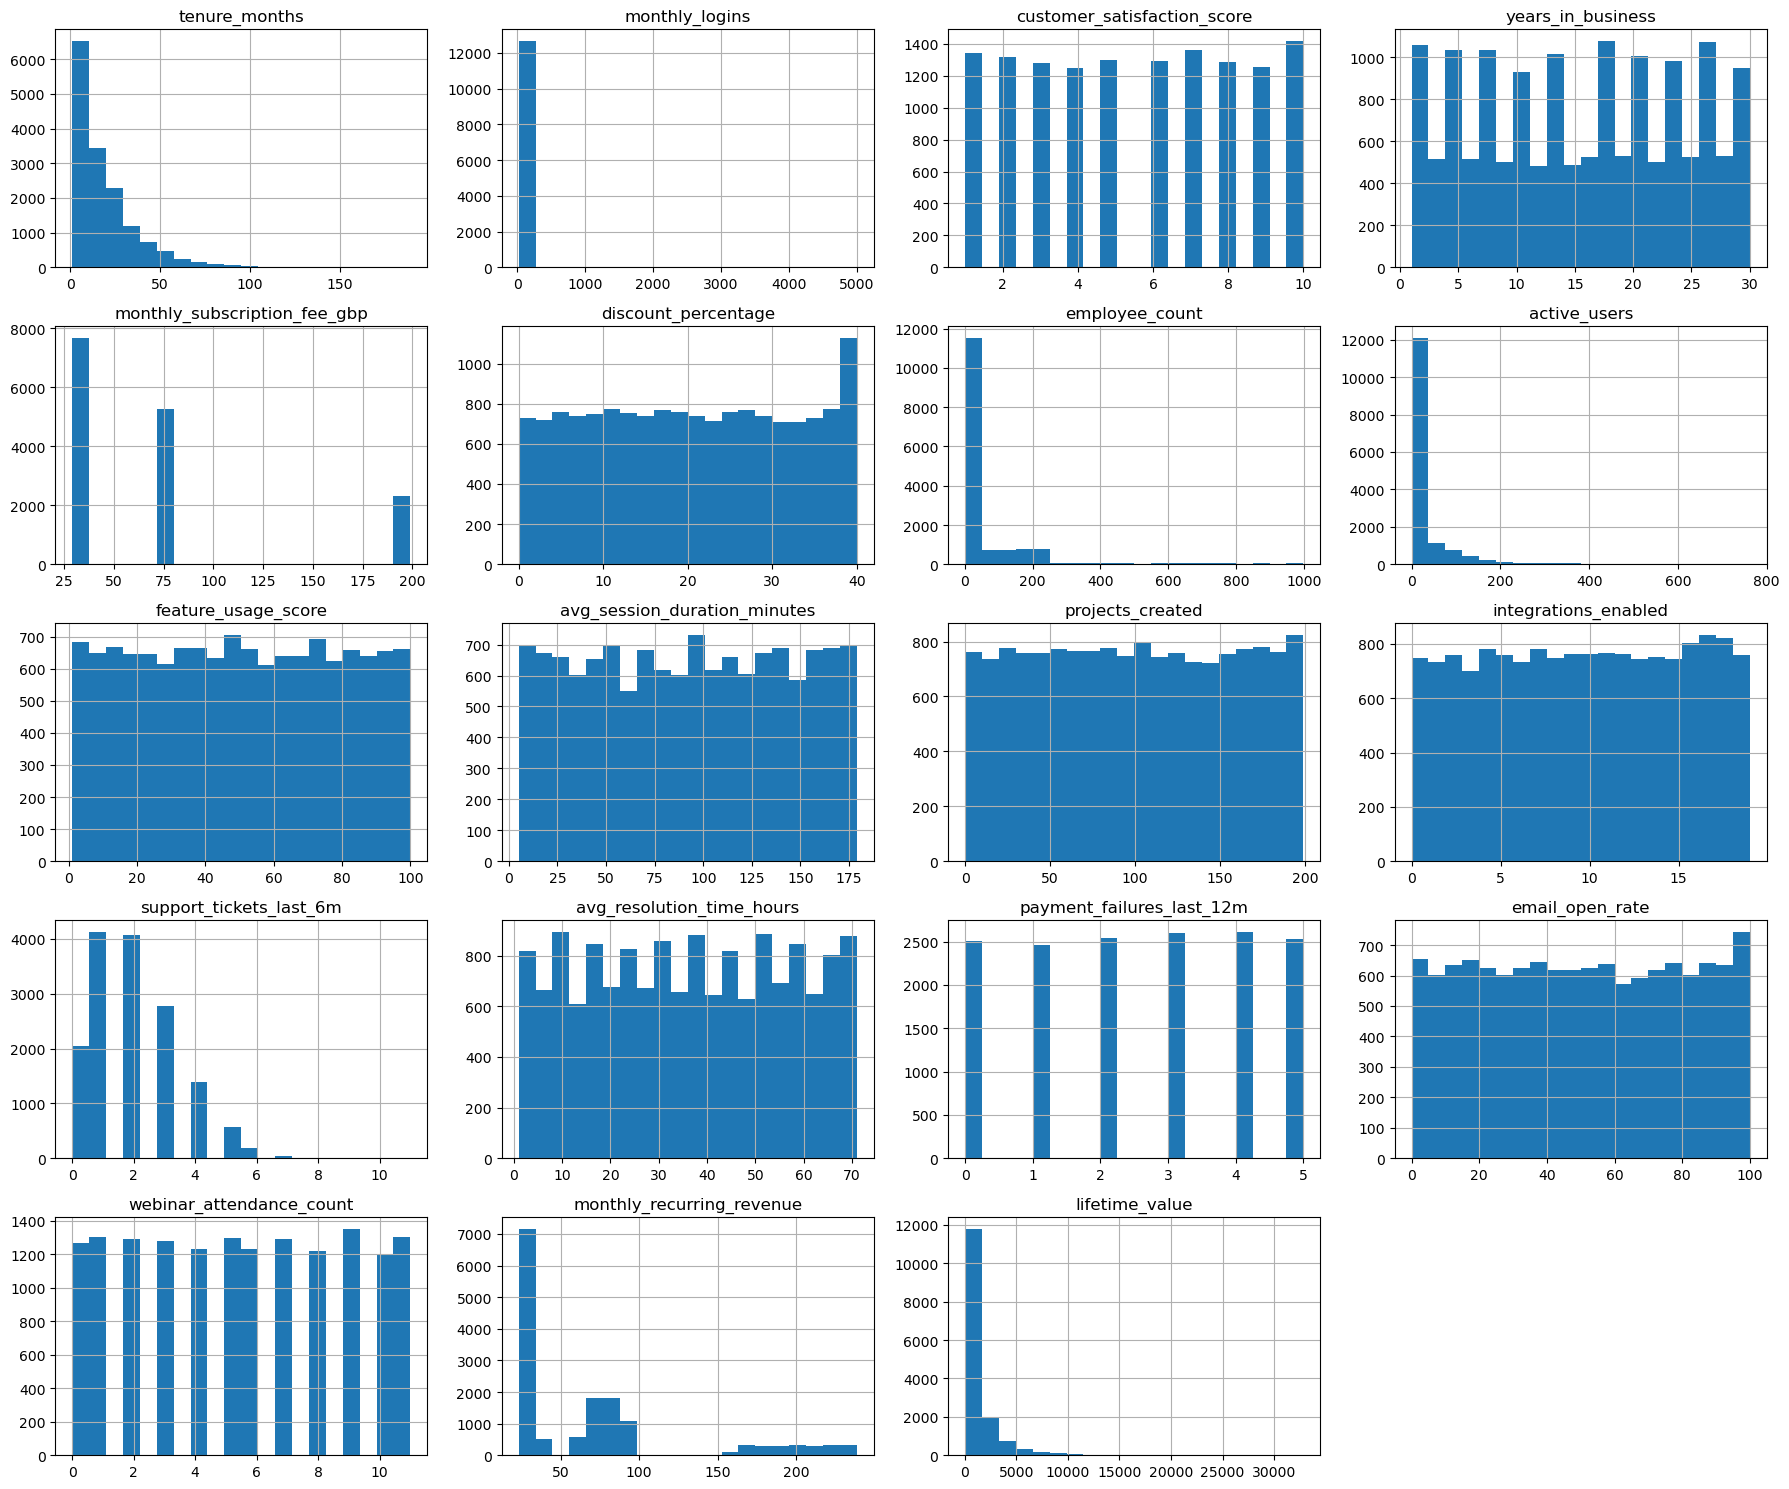

In [16]:
numerical_features = eda_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_features

eda_df[numerical_features].hist(
    figsize=(18,15),
    bins=20
)
plt.tight_layout()

### Insight

The distributions of numerical variables were examined using histograms to better understand customer characteristics, engagement patterns, and revenue behavior.

Several variables, including `tenure_months`, `monthly_logins`, `employee_count`, `active_users`, `monthly_recurring_revenue`, and `lifetime_value`, exhibit positively skewed distributions. This indicates that while most customers fall within lower to moderate ranges, a smaller group of customers contributes substantially higher values.

Variables such as `feature_usage_score`, `avg_session_duration_minutes`, `projects_created`, `integrations_enabled`, `email_open_rate`, `discount_percentage`, and `webinar_attendance_count` appear relatively evenly distributed across their respective ranges.

The `monthly_subscription_fee_gbp` variable displays distinct peaks corresponding to available subscription pricing tiers, while `payment_failures_last_12m` and `support_tickets_last_6m` are concentrated around lower values, indicating that most customers experience relatively few payment or support-related issues.

Overall, the distributions suggest substantial variation in customer engagement, product usage, and revenue contribution across the customer base.

## 3.2 Churn Analysis

### 3.2.1 Overall Churn Rate

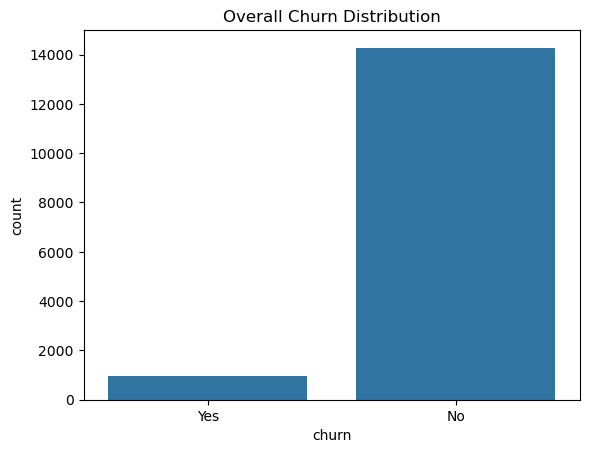

churn
No     93.56
Yes     6.44
Name: proportion, dtype: float64

In [17]:
sns.countplot(
    x="churn",
    data=eda_df
)

plt.title("Overall Churn Distribution")
plt.show()

(
    eda_df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

### Insight

The customer base is highly imbalanced, with **93.56%** of customers remaining active and only **6.44%** having churned.

This suggests that customer retention is generally strong. However, even a relatively small churn rate can have a meaningful impact on recurring revenue and customer lifetime value.

### Modeling Consideration

The target variable is imbalanced and this should be considered during model development. Evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will be used alongside Accuracy to provide a more reliable assessment of model performance.

### 3.2.2 Churn by Subscription Plan

<Axes: xlabel='subscription_plan', ylabel='count'>

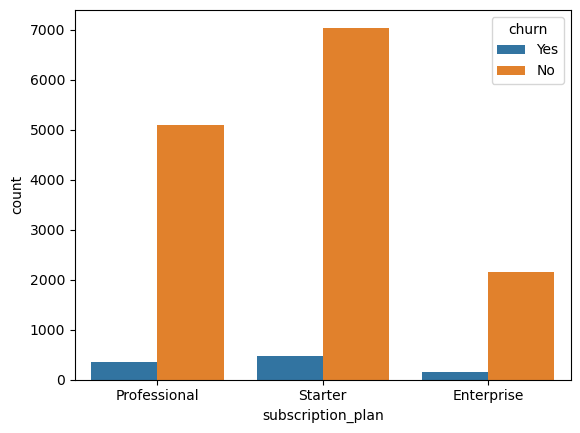

In [18]:
sns.countplot(
    x='subscription_plan',
    hue='churn',
    data=eda_df
)



In [19]:
pd.crosstab(
    eda_df["subscription_plan"],
    eda_df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
subscription_plan,,
Enterprise,93.17,6.83
Professional,93.49,6.51
Starter,93.74,6.26


### Insight

Customer churn is observed across all subscription plans, with relatively similar churn rates across categories.

The Enterprise plan exhibits the highest churn rate (**6.83%**), followed by the Professional plan (**6.51%**) and the Starter plan (**6.26%**). Although the differences are relatively small, the results suggest that subscription plan alone may not be a strong differentiator of customer churn.

### Business Interpretation

The similar churn rates across subscription plans indicate that customers from all plan types are susceptible to churn. Additional factors such as customer engagement, product usage, contract type, support interactions, and satisfaction levels may play a more significant role in influencing retention than subscription tier alone.

### 3.2.3 Churn by Contract Type

<Axes: xlabel='contract_type', ylabel='count'>

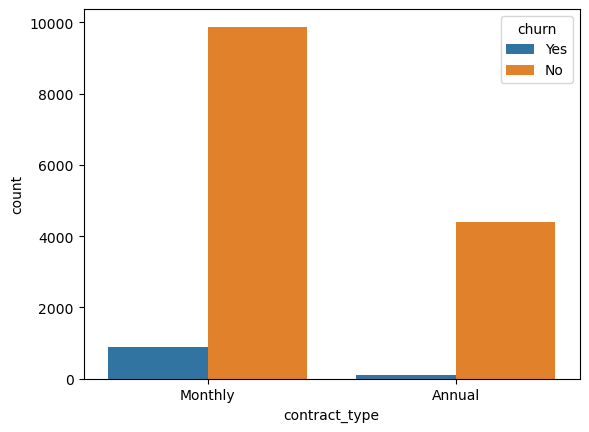

In [20]:
sns.countplot(
    x='contract_type',
    hue='churn',
    data=eda_df
)

In [21]:
pd.crosstab(
    df['contract_type'],
    df['churn'],
    normalize='index'
) * 100

churn,No,Yes
contract_type,,
Annual,97.73913,2.26087
Monthly,91.84990,8.15010


### Insight

Contract type has a strong relationship with customer churn. Customers on annual contracts have a churn rate of **2.26%**, compared to **8.15%** for customers on monthly contracts.

This indicates that customers with longer-term commitments are substantially more likely to remain with the platform, while monthly subscribers are more prone to churn.

### Business Interpretation

The results suggest that annual contracts contribute to stronger customer retention and more predictable recurring revenue. Encouraging customers to transition from monthly to annual plans through incentives or discounts may help reduce churn and improve customer lifetime value.

### 3.2.4 Churn by Region

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'North West'),
  Text(1, 0, 'East Midlands'),
  Text(2, 0, 'Scotland'),
  Text(3, 0, 'West Midlands'),
  Text(4, 0, 'South West'),
  Text(5, 0, 'North East'),
  Text(6, 0, 'South East'),
  Text(7, 0, 'London'),
  Text(8, 0, 'Wales')])

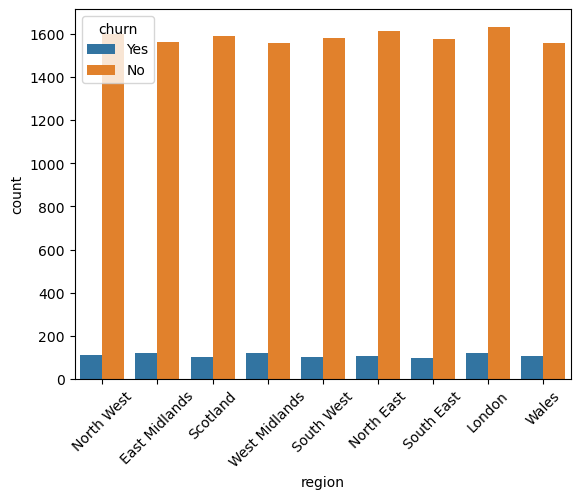

In [22]:
sns.countplot(
    x='region',
    hue='churn',
    data=eda_df
)
plt.xticks(rotation=45)

In [23]:
pd.crosstab(
    eda_df["region"],
    eda_df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
region,,
East Midlands,92.93,7.07
London,93.10,6.90
North East,93.84,6.16
North West,93.46,6.54
Scotland,93.97,6.03
South East,94.31,5.69
South West,93.89,6.11
Wales,93.64,6.36
West Midlands,92.95,7.05


### Insight

Customer churn rates are relatively similar across all regions, ranging from **5.69%** in the South East to **7.07%** in the East Midlands.

Although minor regional differences exist, the variation in churn rates is relatively small, suggesting that geographic location is not a major driver of customer churn within the dataset.

### Business Interpretation

The findings indicate that customer retention challenges are broadly consistent across regions. Factors such as customer engagement, contract type, product usage, and support interactions are likely to have a greater influence on churn than geographic location.

As a result, retention strategies may be more effective when focused on customer behavior and service experience rather than region-specific initiatives.

### 3.2.5 Churn by Industry

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Technology'),
  Text(1, 0, 'Retail'),
  Text(2, 0, 'Healthcare'),
  Text(3, 0, 'Logistics'),
  Text(4, 0, 'Education'),
  Text(5, 0, 'Manufacturing'),
  Text(6, 0, 'Finance')])

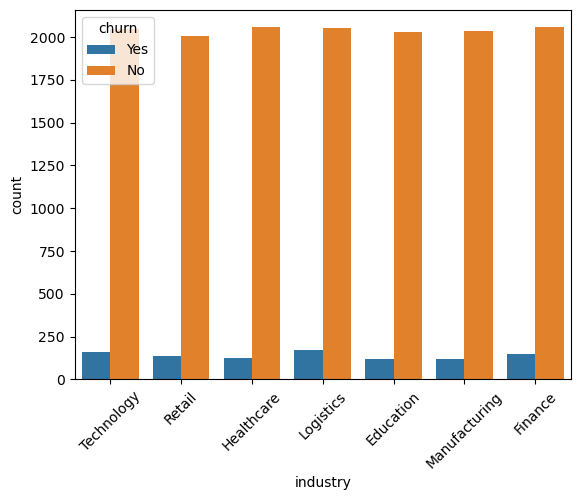

In [24]:
sns.countplot(
    x='industry',
    hue='churn',
    data=eda_df
)
plt.xticks(rotation=45)

In [25]:
pd.crosstab(
    eda_df["industry"],
    eda_df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
industry,,
Education,94.32,5.68
Finance,93.37,6.63
Healthcare,94.14,5.86
Logistics,92.27,7.73
Manufacturing,94.56,5.44
Retail,93.61,6.39
Technology,92.74,7.26


### Insight

Customer churn varies across industries, although the differences are relatively moderate.

The Logistics industry exhibits the highest churn rate (**7.73%**), followed by Technology (**7.26%**) and Finance (**6.63%**). In contrast, Manufacturing (**5.44%**), Education (**5.68%**), and Healthcare (**5.86%**) show comparatively lower churn rates.

These results suggest that industry characteristics may influence customer retention, although the impact appears less pronounced than factors such as contract type.

### Business Interpretation

Customers operating in Logistics and Technology may face business environments or operational requirements that contribute to higher churn rates. Understanding the specific needs and challenges of these industries could help the organization develop targeted retention strategies.

Since churn is observed across all industries, retention initiatives should focus not only on industry-specific factors but also on customer engagement, product adoption, and overall service experience.

## 3.3 Numerical Features vs Churn

## Boxplots

### 3.3.1 Tenure vs Churn

<Axes: xlabel='churn', ylabel='tenure_months'>

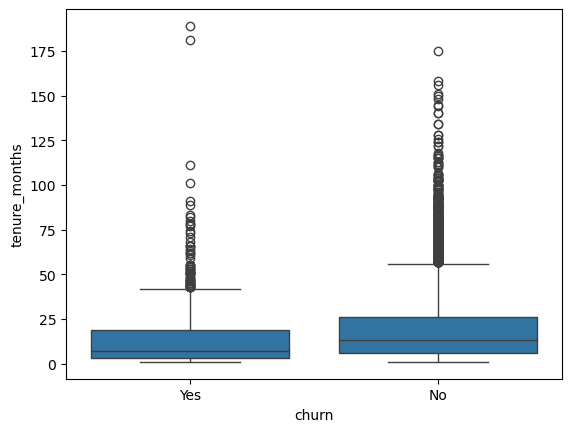

In [26]:
sns.boxplot(
    x='churn',
    y='tenure_months',
    data=eda_df
)

In [27]:
eda_df.groupby("churn")["tenure_months"].median()

churn
No     13.0
Yes     7.0
Name: tenure_months, dtype: float64

### Insight

Customer tenure shows a strong relationship with churn behavior.

The median tenure of retained customers is **13 months**, compared to **7 months** for customers who churned. In addition, the boxplot indicates that retained customers generally exhibit higher tenure values and a wider distribution of long-term customer relationships.

These findings suggest that customers are more likely to churn during the earlier stages of their relationship with the platform, while longer-tenure customers tend to remain active.

### Business Interpretation

The results highlight the importance of customer retention efforts during the early stages of the customer lifecycle. Strengthening onboarding, improving product adoption, and increasing customer engagement during the first few months may help reduce churn and improve long-term retention.

### 3.3.2 Monthly Logins vs Churn

<Axes: xlabel='churn', ylabel='monthly_logins'>

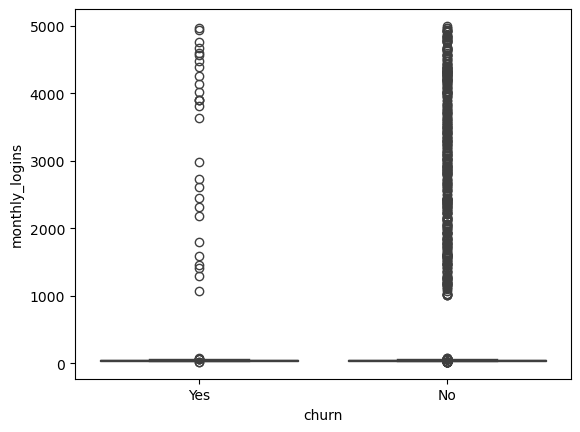

In [28]:
sns.boxplot(
    x='churn',
    y='monthly_logins',
    data=eda_df
)

<Axes: xlabel='churn', ylabel='monthly_logins'>

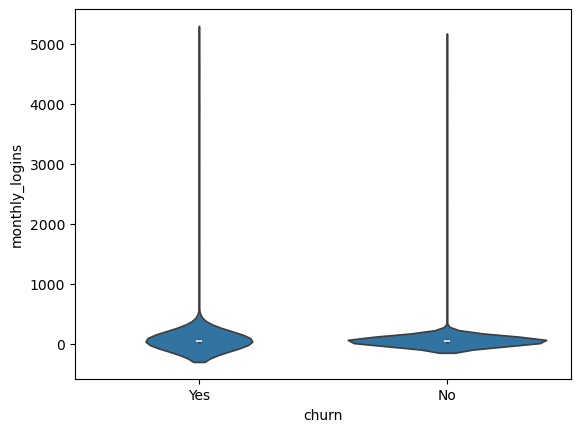

In [29]:
sns.violinplot(
    x="churn",
    y="monthly_logins",
    data=eda_df
)

In [30]:
eda_df.groupby("churn")["monthly_logins"].median()

churn
No     45.0
Yes    45.0
Name: monthly_logins, dtype: float64

In [31]:
eda_df.groupby("churn")["monthly_logins"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,12285.0,142.960684,569.056322,21.0,41.0,45.0,50.0,4999.0
Yes,838.0,154.360382,631.312404,24.0,41.0,45.0,50.0,4968.0


In [32]:
eda_df.groupby("churn")["monthly_logins"].agg(
    ["median", "mean", "min", "max"]
)

,median,mean,min,max
churn,,,,
No,45.0,142.960684,21.0,4999.0
Yes,45.0,154.360382,24.0,4968.0


### Insight

Monthly login activity appears to have little influence on customer churn.

Both churned and retained customers have an identical median of **45 monthly logins**, and the overall distributions are highly similar. This suggests that login frequency alone is not a strong indicator of whether a customer will remain with or leave the platform.

### Business Interpretation

The findings indicate that simply measuring how often customers access the platform may not be sufficient to identify churn risk. More meaningful indicators such as feature adoption, customer satisfaction, support interactions, and contract type may provide better insights into customer retention behavior.

### 3.3.3 Satisfaction vs Churn

<Axes: xlabel='churn', ylabel='customer_satisfaction_score'>

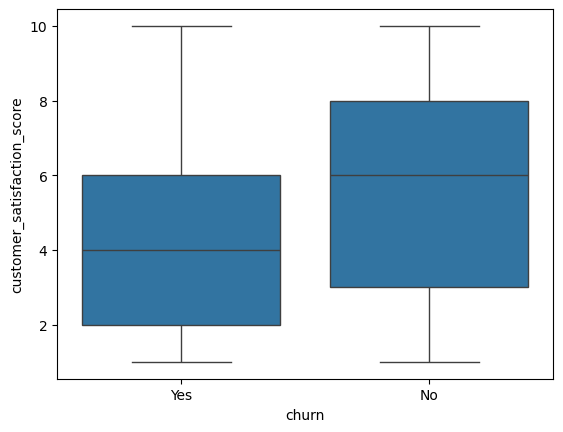

In [33]:
sns.boxplot(
    x='churn',
    y='customer_satisfaction_score',
    data=eda_df
)

In [34]:
eda_df.groupby("churn")["customer_satisfaction_score"].median()

churn
No     6.0
Yes    4.0
Name: customer_satisfaction_score, dtype: float64

In [35]:
eda_df.groupby("churn")["customer_satisfaction_score"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,12241.0,5.613512,2.885853,1.0,3.0,6.0,8.0,10.0
Yes,854.0,4.255269,2.767749,1.0,2.0,4.0,6.0,10.0


### Insight

Customer satisfaction shows a strong relationship with churn behavior.

Retained customers have a higher median satisfaction score (**6**) compared to customers who churned (**4**). The overall distribution also indicates that retained customers consistently report higher satisfaction levels.

These findings suggest that customers with lower satisfaction are more likely to discontinue their subscription.

### Business Interpretation

Improving customer satisfaction through better product experience, faster issue resolution, and proactive customer support may help reduce churn. Monitoring satisfaction scores can also help identify customers who may require additional engagement before they decide to leave the platform.

### 3.3.4 Feature Usage vs Churn

<Axes: xlabel='churn', ylabel='feature_usage_score'>

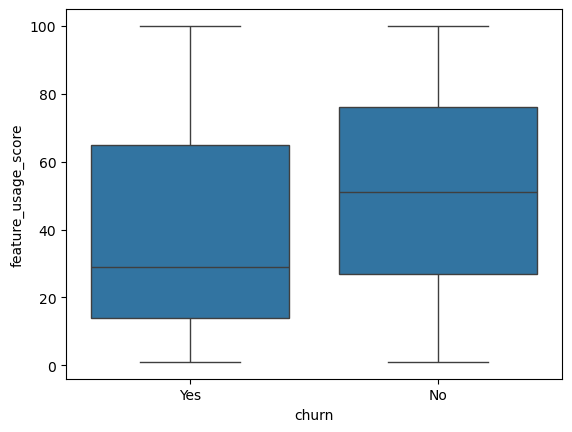

In [36]:
sns.boxplot(
    x='churn',
    y='feature_usage_score',
    data=eda_df
)

In [42]:
eda_df.groupby("churn")["feature_usage_score"].agg(
    ["median", "mean"]
)

,median,mean
churn,,
No,51.0,51.124683
Yes,29.0,39.589091


### Insight

Feature usage score shows a strong relationship with customer churn.

Retained customers have a median feature usage score of **51**, compared to **29** for customers who churned. This indicates that customers who actively utilize more product features are considerably more likely to remain with the platform.

### Business Interpretation

The findings suggest that increasing product adoption may help improve customer retention. Encouraging customers to explore and regularly use key platform features through onboarding, training, and in-app guidance could reduce churn and increase long-term customer engagement.

## Correlation Analysis

## 3.3.5 Heatmap

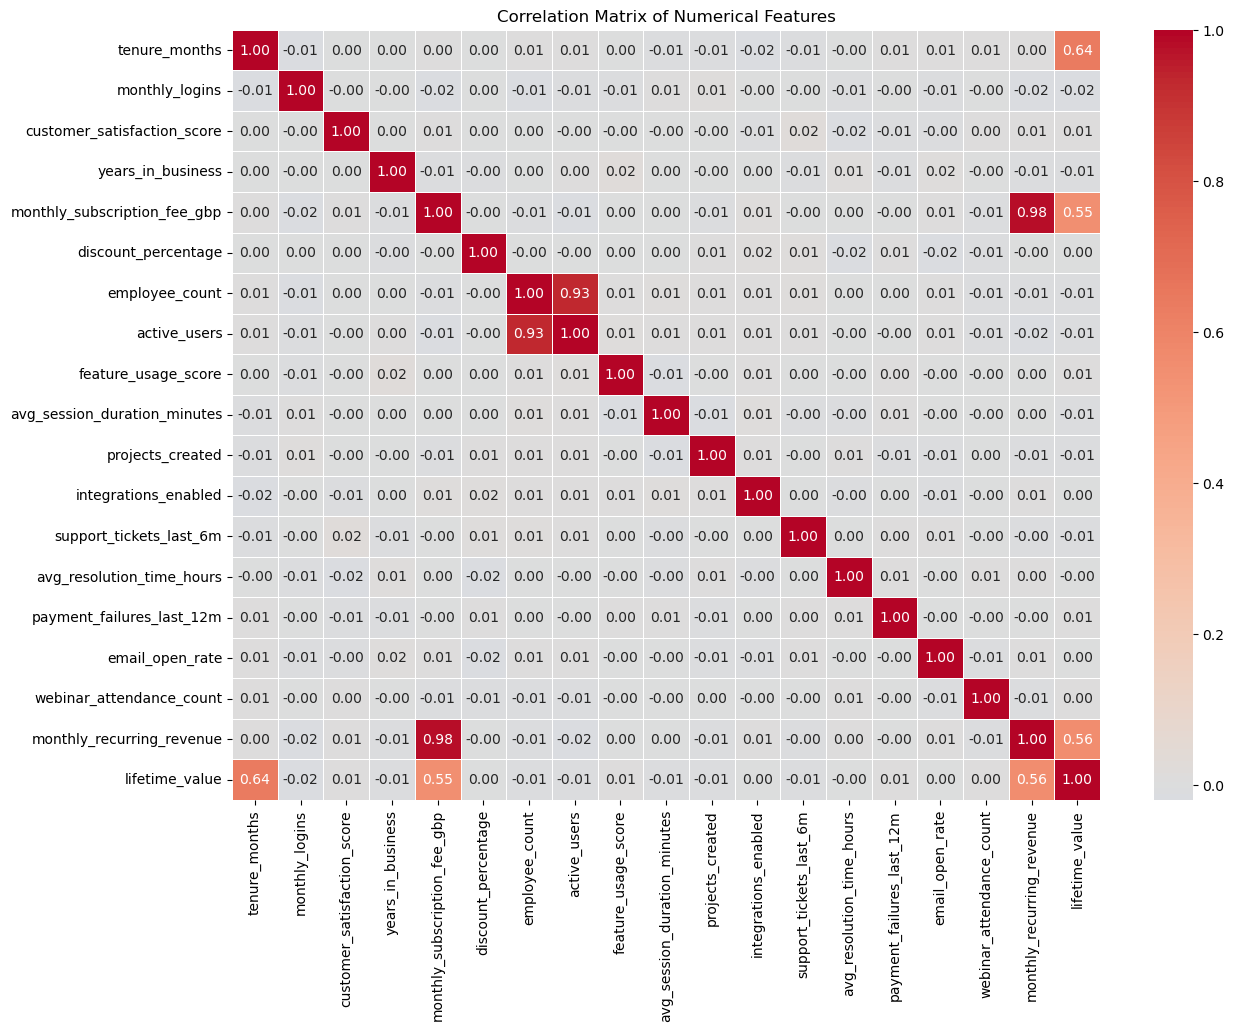

In [44]:
plt.figure(figsize=(14, 10))

corr_matrix = eda_df[numerical_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [43]:
corr_matrix = eda_df[numerical_features].corr()

strong_corr = (
    corr_matrix
    .where(abs(corr_matrix) >= 0.7)
    .stack()
)

strong_corr = strong_corr[
    strong_corr.index.get_level_values(0)
    != strong_corr.index.get_level_values(1)
]

strong_corr.drop_duplicates()

monthly_subscription_fee_gbp  monthly_recurring_revenue    0.983604
employee_count                active_users                 0.931424
dtype: float64

### Insight

Correlation analysis identified two strong positive relationships among the numerical variables.

- **Monthly Subscription Fee** and **Monthly Recurring Revenue** exhibit a very strong positive correlation (**r = 0.98**), indicating that customers paying higher subscription fees contribute proportionally higher recurring revenue.
- **Employee Count** and **Active Users** also show a strong positive correlation (**r = 0.93**), suggesting that larger organizations generally have more active platform users.

Apart from these relationships, the remaining numerical variables exhibit weak to moderate correlations, indicating limited multicollinearity across the dataset.

### Business Interpretation

The identified correlations align with expected business behavior and do not indicate data quality issues. Most numerical features capture different aspects of customer behavior, engagement, and financial performance, providing diverse information for churn prediction.

## Revenue Analysis

### 3.3.6 Monthly Recurring Revenue vs Churn

<Axes: xlabel='churn', ylabel='monthly_recurring_revenue'>

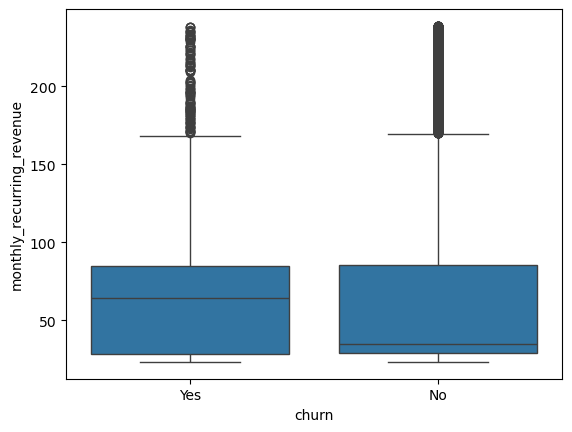

In [52]:
sns.boxplot(
    x='churn',
    y='monthly_recurring_revenue',
    data=eda_df
)

In [53]:
eda_df.groupby("churn")["monthly_recurring_revenue"].agg(
    ["median", "mean", "min", "max"]
)

,median,mean,min,max
churn,,,,
No,34.690,71.970829,23.20,238.77
Yes,64.345,71.470682,23.21,238.39


### Insight

Monthly recurring revenue shows a noticeable difference between churned and retained customers. Churned customers have a higher median monthly recurring revenue (£64.35) than retained customers (£34.69), while the mean revenue is nearly identical across both groups due to the presence of high-value customers in each category.

### Business Interpretation

The results suggest that higher-paying customers are not necessarily less likely to churn. Revenue alone does not appear to guarantee customer retention, indicating that other factors such as customer satisfaction, product adoption, and contract type may play a more significant role in influencing churn.

### 3.3.7 Lifetime Value by churn

<Axes: xlabel='churn', ylabel='lifetime_value'>

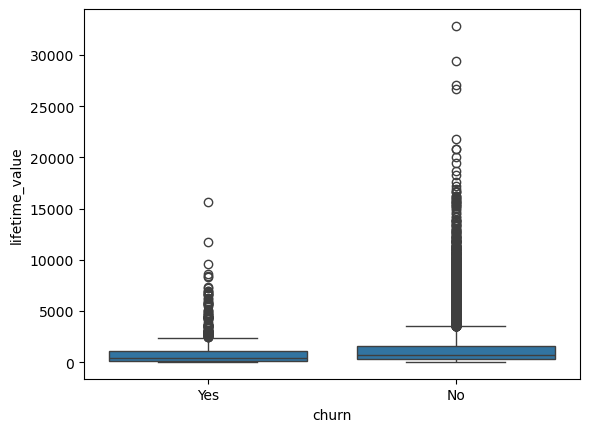

In [54]:
sns.boxplot(
    x='churn',
    y='lifetime_value',
    data=eda_df
)

In [55]:
eda_df.groupby("churn")["lifetime_value"].agg(
    ["median", "mean", "min", "max"]
)

,median,mean,min,max
churn,,,,
No,670.32,1356.639017,23.21,32841.20
Yes,408.51,939.682342,23.57,15673.83


### Insight

Lifetime value shows a strong relationship with customer churn. Retained customers have a higher median lifetime value (£670.32) than churned customers (£408.51), with the mean lifetime value also substantially higher among retained customers.

### Business Interpretation

Customers who remain with the platform generate greater long-term value for the business. This highlights the importance of customer retention strategies, as reducing churn can significantly increase overall customer lifetime value and long-term revenue.

####

## 4. Key Findings

- The dataset is highly imbalanced, with only 6.44% of customers churning.
- Customers on monthly contracts exhibit substantially higher churn than those on annual contracts.
- Shorter customer tenure is strongly associated with churn.
- Lower customer satisfaction scores are observed among churned customers.
- Customers with lower feature usage scores are more likely to churn.
- Retained customers generate higher lifetime value than churned customers.
- Monthly recurring revenue alone is not a strong indicator of churn.
- Correlation analysis revealed no severe multicollinearity, except for expected business relationships between subscription fee and monthly recurring revenue, and employee count and active users.